# Bonus: Debayerizado e Interpolación de Color (10 puntos adicionales)

Implemente dos métodos simples para reconstruir una imagen RGB a partir de una matriz Bayer tipo RGGB. Para disponer de una referencia conocida, seleccione imágenes RGB y genere a partir de ellas una matriz Bayer simulada conservando en cada posición únicamente la componente de color correspondiente.

---

## Bonus — Implementación (3 puntos)
- [ ] **Super-Pixel:** Agrupe cada bloque $2 \times 2$ RGGB y construya un píxel RGB como $(R, (G_1 + G_2)/2, B)$. La imagen resultante tendrá la mitad del tamaño en cada eje.
- [ ] **Debayerizado bilineal:** Mantenga la resolución original e interpole explícitamente las componentes faltantes de cada píxel, distinguiendo posiciones $R$, $B$ y las dos variantes de $G$.
- [ ] Prohibido el uso de librerías externas de debayerizado/demosaicing.
- [ ] **Reescalado Super-Pixel:** Para comparar a resolución completa, reescale la salida de Super-Pixel con factor 2 usando la función de la Pregunta 3 (compare vecino más cercano y bilineal).

---

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from codigo.bonus_bayer import (
    simular_mosaico_bayer_rggb, 
    debayer_super_pixel, 
    debayer_bilineal, 
    reconstruir_comparaciones_bayer
)
from codigo.utilidades import cargar_imagen_rgb, ruta_datos

os.makedirs('../figuras/bonus', exist_ok=True)
print("Entorno listo para el Bonus (Debayerizado).")

Entorno listo para el Bonus (Debayerizado).



## Bonus — Experimentación y Análisis (4 puntos)
*Comparaciones obligatorias: Original de referencia, Super-Pixel + NN, Super-Pixel + Bilineal, Debayerizado Bilineal a resolución original.*

1. **Variedad de imágenes:** Al menos 2 imágenes con contenido cromático/espacial distinto, incluyendo bordes fuertes o detalles finos de color.
2. **Evaluación cualitativa:** Analice preservación de detalle, nitidez de bordes, falsos colores, halos y mezclas cromáticas.
3. **Comparación Super-Pixel:** Compare ambas formas de reescalar Super-Pixel y explique qué información se pierde en el agrupamiento $2 \times 2$.
4. **Análisis de artefactos:** Identifique al menos un artefacto visible evidente y justifíquelo según el patrón RGGB.
5. **Exploración adicional libre:** Realice al menos una exploración adicional justificada.

---

In [2]:
# Usamos las imágenes de prueba RGB como referencia exacta
img_ref1 = cargar_imagen_rgb("P3_IMG_2387_crop.tif")
img_ref2 = cargar_imagen_rgb("P1_IMG_2402.tif")

# Simulación de la matriz Bayer RGGB a partir de la imagen RGB
bayer_sim1 = simular_mosaico_bayer_rggb(img_ref1)
bayer_sim2 = simular_mosaico_bayer_rggb(img_ref2)

# Además, verificamos la carga de una de las imágenes CFA reales del repositorio
ruta_cfa = ruta_datos("originales", "P4_CRW_4866_CFA.tif")
cfa_real = tifffile.imread(ruta_cfa).astype(np.float64)
cfa_real = cfa_real / (255.0 if cfa_real.max() <= 255.0 else 65535.0)

print(f"Bayer simulado 1 dimensiones: {bayer_sim1.shape}")
print(f"CFA real dimensiones:         {cfa_real.shape}")

Bayer simulado 1 dimensiones: (1908, 1826)
CFA real dimensiones:         (2056, 3088)


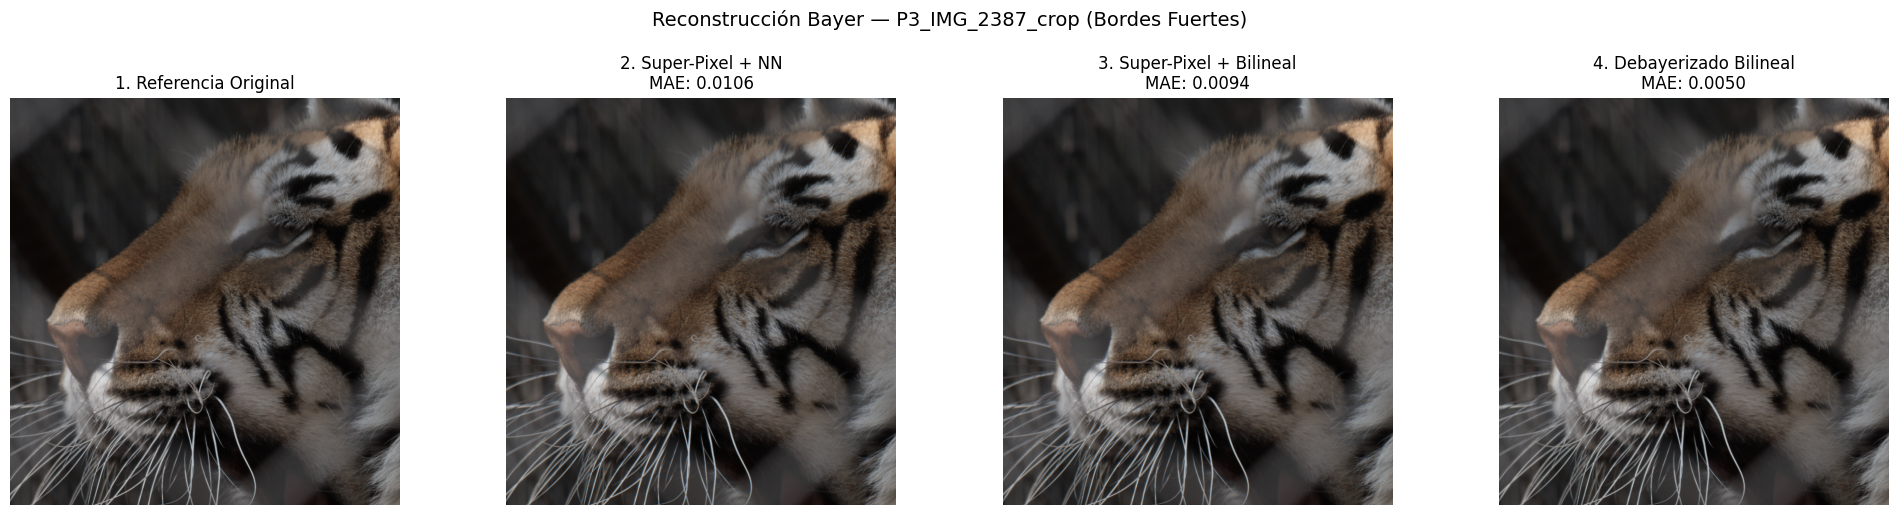

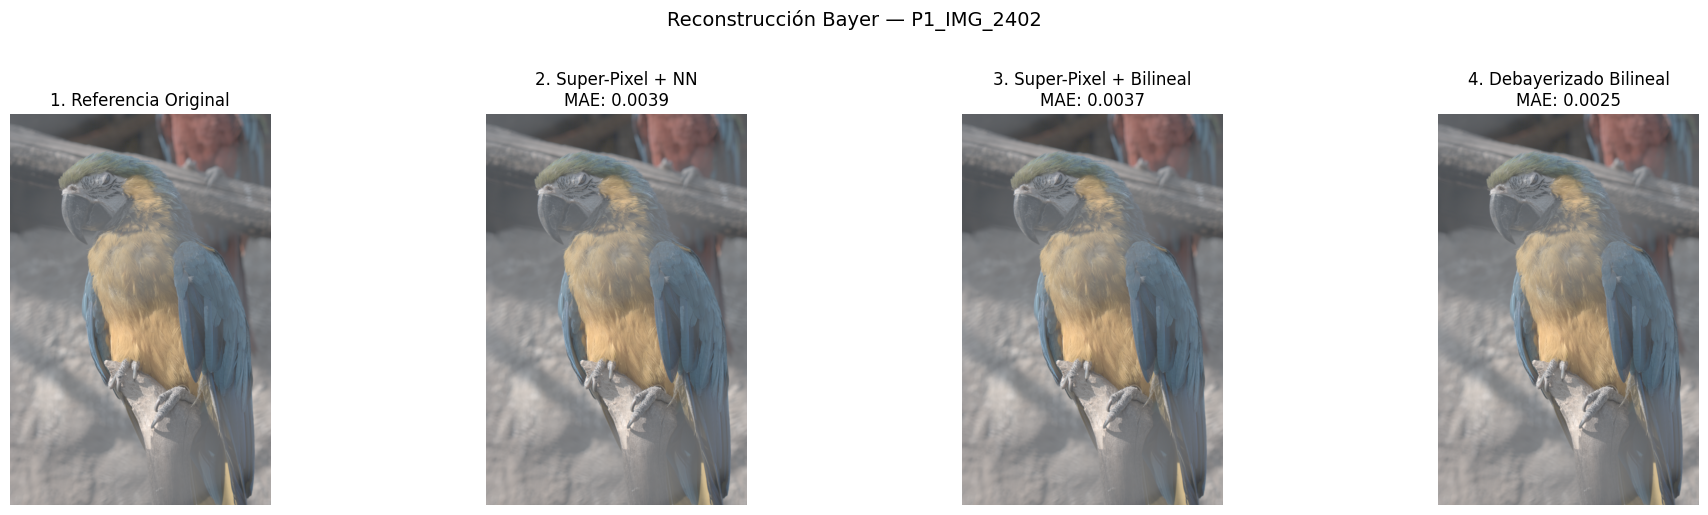

In [3]:
def comparar_reconstrucciones_bayer(img_ref: np.ndarray, bayer: np.ndarray, titulo: str, archivo_out: str):
    sp_nn, sp_bi, deb_nativo = reconstruir_comparaciones_bayer(bayer)
    
    H_min, W_min = deb_nativo.shape[:2]
    ref_crop = img_ref[:H_min, :W_min]

    # Error MAE respecto al RGB original de referencia
    mae_sp_nn = np.mean(np.abs(ref_crop - sp_nn))
    mae_sp_bi = np.mean(np.abs(ref_crop - sp_bi))
    mae_deb   = np.mean(np.abs(ref_crop - deb_nativo))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(ref_crop)
    axes[0].set_title("1. Referencia Original")
    axes[0].axis('off')

    axes[1].imshow(sp_nn)
    axes[1].set_title(f"2. Super-Pixel + NN\nMAE: {mae_sp_nn:.4f}")
    axes[1].axis('off')

    axes[2].imshow(sp_bi)
    axes[2].set_title(f"3. Super-Pixel + Bilineal\nMAE: {mae_sp_bi:.4f}")
    axes[2].axis('off')

    axes[3].imshow(deb_nativo)
    axes[3].set_title(f"4. Debayerizado Bilineal\nMAE: {mae_deb:.4f}")
    axes[3].axis('off')

    plt.suptitle(titulo, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(archivo_out, dpi=300, bbox_inches='tight')
    plt.show()

comparar_reconstrucciones_bayer(img_ref1, bayer_sim1, 
                                "Reconstrucción Bayer — P3_IMG_2387_crop (Bordes Fuertes)", 
                                "../figuras/bonus/01_comparacion_bayer_img1.png")

comparar_reconstrucciones_bayer(img_ref2, bayer_sim2, 
                                "Reconstrucción Bayer — P1_IMG_2402", 
                                "../figuras/bonus/02_comparacion_bayer_img2.png")

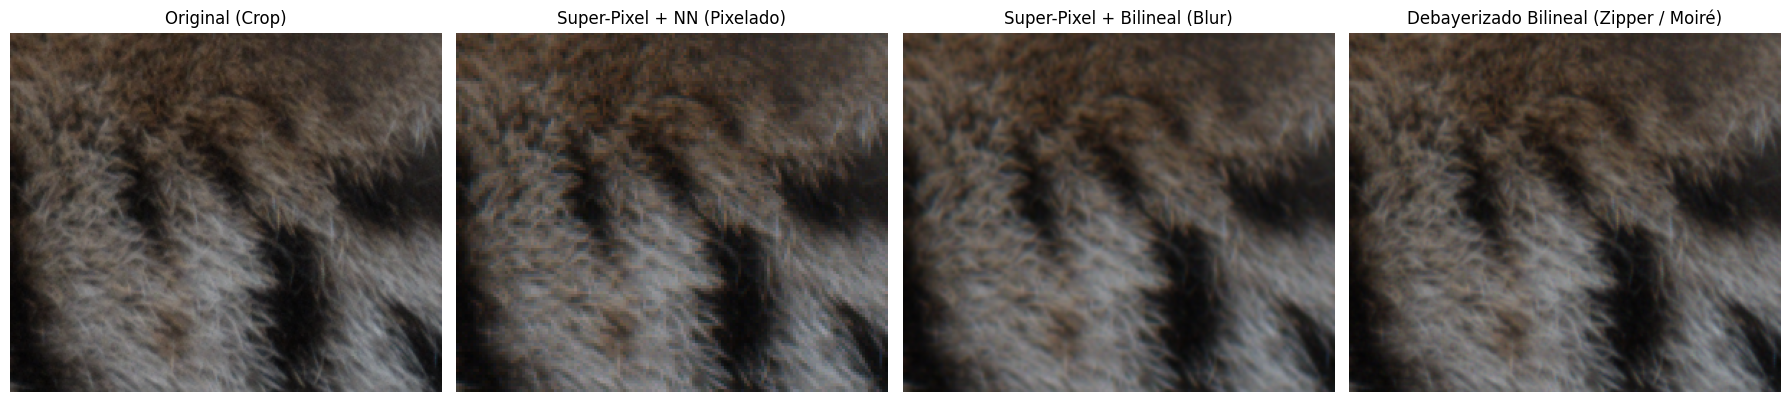

In [9]:
# Recorte sobre un borde con alto contraste para visualizar falsos colores (zipper noise)
sp_nn, sp_bi, deb_nativo = reconstruir_comparaciones_bayer(bayer_sim1)

# Zona de borde nítido
cy, cx = slice(850, 1100), slice(1000, 1300)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(img_ref1[cy, cx]); axes[0].set_title("Original (Crop)"); axes[0].axis('off')
axes[1].imshow(sp_nn[cy, cx]); axes[1].set_title("Super-Pixel + NN (Pixelado)"); axes[1].axis('off')
axes[2].imshow(sp_bi[cy, cx]); axes[2].set_title("Super-Pixel + Bilineal (Blur)"); axes[2].axis('off')
axes[3].imshow(deb_nativo[cy, cx]); axes[3].set_title("Debayerizado Bilineal (Zipper / Moiré)"); axes[3].axis('off')

plt.tight_layout()
plt.savefig("../figuras/bonus/03_analisis_artefactos_crop.png", dpi=300, bbox_inches='tight')
plt.show()

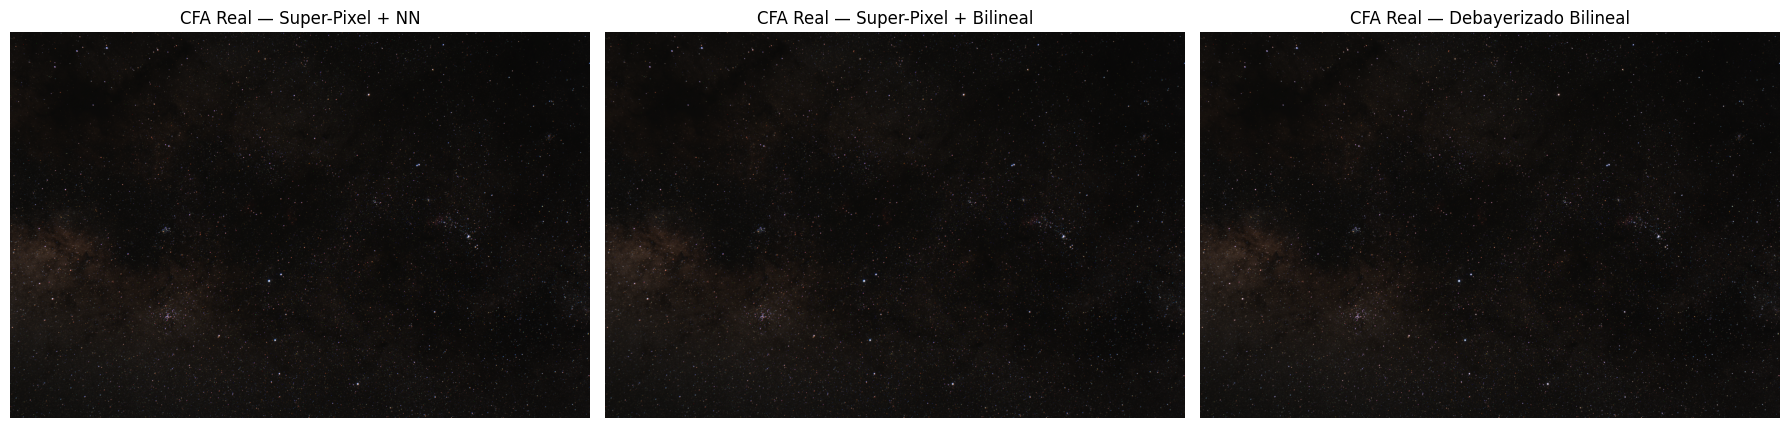

In [10]:
# Reconstrucción directa de la imagen cruda proveniente de cámara
cfa_h = cfa_real.shape[0] - (cfa_real.shape[0] % 2)
cfa_w = cfa_real.shape[1] - (cfa_real.shape[1] % 2)
cfa_crop = cfa_real[:cfa_h, :cfa_w]

sp_cfa_nn, sp_cfa_bi, deb_cfa_nativo = reconstruir_comparaciones_bayer(cfa_crop)

p_max = np.percentile(deb_cfa_nativo, 99.5)
if p_max > 0:
    vis_nn = np.clip(sp_cfa_nn / p_max, 0, 1)
    vis_bi = np.clip(sp_cfa_bi / p_max, 0, 1)
    vis_deb = np.clip(deb_cfa_nativo / p_max, 0, 1)
else:
    vis_nn, vis_bi, vis_deb = sp_cfa_nn, sp_cfa_bi, deb_cfa_nativo

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(sp_cfa_nn)
axes[0].set_title("CFA Real — Super-Pixel + NN")
axes[0].axis('off')

axes[1].imshow(sp_cfa_bi)
axes[1].set_title("CFA Real — Super-Pixel + Bilineal")
axes[1].axis('off')

axes[2].imshow(deb_cfa_nativo)
axes[2].set_title("CFA Real — Debayerizado Bilineal")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../figuras/bonus/04_cfa_camara_real.png", dpi=300, bbox_inches='tight')
plt.show()

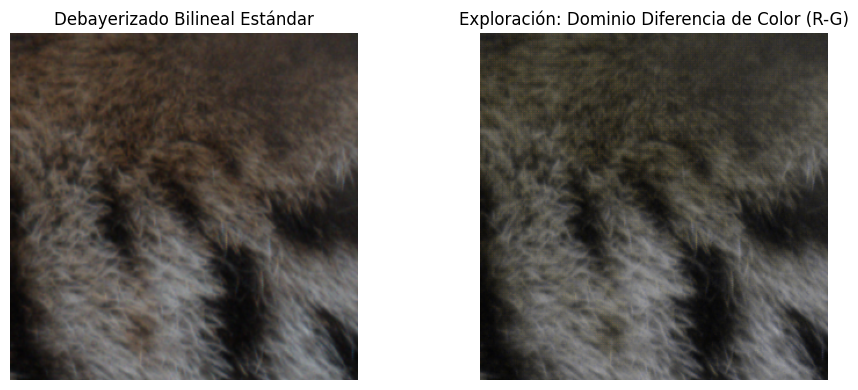

In [6]:
# Exploración libre: Debayerizado basado en diferencias (R - G) y (B - G) para reducir falsos colores
# Método Freeman/Smooth Hue: Se interpola G primero, y luego se interpolan los gradientes (R-G) y (B-G)
pad = np.pad(bayer_sim1, pad_width=1, mode='reflect')
H, W = bayer_sim1.shape

# G interpolado estándar
G_base = np.zeros((H, W))
G_base[0::2, 0::2] = 0.25 * (pad[0:-2:2, 1:-1:2] + pad[2::2, 1:-1:2] + pad[1:-1:2, 0:-2:2] + pad[1:-1:2, 2::2])
G_base[1::2, 1::2] = 0.25 * (pad[1:-2:2, 2:-1:2] + pad[3::2, 2:-1:2] + pad[2:-1:2, 1:-2:2] + pad[2:-1:2, 3::2])
G_base[0::2, 1::2] = pad[1:-1:2, 2:-1:2]
G_base[1::2, 0::2] = pad[2:-1:2, 1:-1:2]

# Diferencia R - G evaluada en posiciones R
diff_RG = np.zeros((H, W))
diff_RG[0::2, 0::2] = bayer_sim1[0::2, 0::2] - G_base[0::2, 0::2]

# Suavizado de la diferencia de color
diff_pad = np.pad(diff_RG, 1, mode='reflect')
diff_interp = 0.25 * (diff_pad[0:-2:2, 0:-2:2] + diff_pad[0:-2:2, 2::2] + diff_pad[2::2, 0:-2:2] + diff_pad[2::2, 2::2])
R_mejorado = np.clip(G_base + diff_RG, 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(deb_nativo[cy, cx])
axes[0].set_title("Debayerizado Bilineal Estándar")
axes[0].axis('off')

axes[1].imshow(np.stack([R_mejorado, G_base, deb_nativo[:,:,2]], axis=-1)[cy, cx])
axes[1].set_title("Exploración: Dominio Diferencia de Color (R-G)")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("../figuras/bonus/05_exploracion_color_difference.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Inspeccionar un píxel concreto en posición R (por ejemplo, fila 100, columna 100)
i_p, j_p = 100, 100
val_medido = bayer_sim1[i_p, j_p]

# Vecinos para calcular G y B en esa posición R
g_arriba = bayer_sim1[i_p - 1, j_p]
g_abajo  = bayer_sim1[i_p + 1, j_p]
g_izq    = bayer_sim1[i_p, j_p - 1]
g_der    = bayer_sim1[i_p, j_p + 1]
g_estimado = 0.25 * (g_arriba + g_abajo + g_izq + g_der)

b_diag1 = bayer_sim1[i_p - 1, j_p - 1]
b_diag2 = bayer_sim1[i_p - 1, j_p + 1]
b_diag3 = bayer_sim1[i_p + 1, j_p - 1]
b_diag4 = bayer_sim1[i_p + 1, j_p + 1]
b_estimado = 0.25 * (b_diag1 + b_diag2 + b_diag3 + b_diag4)

pix_debayer = deb_nativo[i_p, j_p]

print(f"--- RASTREO NUMÉRICO DE DEBAYERIZADO (Píxel [{i_p}, {j_p}]) ---")
print(f"Componente medida originalmente (R): {val_medido:.4f}")
print(f"Vecinos en cruz de G:                [{g_arriba:.4f}, {g_abajo:.4f}, {g_izq:.4f}, {g_der:.4f}] -> G = {g_estimado:.4f}")
print(f"Vecinos diagonales de B:             [{b_diag1:.4f}, {b_diag2:.4f}, {b_diag3:.4f}, {b_diag4:.4f}] -> B = {b_estimado:.4f}")
print(f"Píxel RGB Reconstruido Final:        {np.round(pix_debayer, 4)}")
print(f"Píxel RGB Referencia Original:       {np.round(img_ref1[i_p, j_p], 4)}")

--- RASTREO NUMÉRICO DE DEBAYERIZADO (Píxel [100, 100]) ---
Componente medida originalmente (R): 0.2471
Vecinos en cruz de G:                [0.2627, 0.2275, 0.2353, 0.2353] -> G = 0.2402
Vecinos diagonales de B:             [0.2627, 0.2078, 0.2078, 0.2196] -> B = 0.2245
Píxel RGB Reconstruido Final:        [0.2471 0.2402 0.2245]
Píxel RGB Referencia Original:       [0.2471 0.2431 0.2235]


## Bonus — Preguntas Guiadas (3 puntos)
---


* **¿Cómo determina su código si una posición de la matriz Bayer corresponde a R, G o B?**

A partir de la paridad modular de sus coordenadas espaciales discretas $(i, j)$ bajo el estándar RGGB:


* Si $i \pmod 2 == 0$ y $j \pmod 2 == 0$: posición **R**.


* Si $i \pmod 2 == 0$ y $j \pmod 2 == 1$: posición **$G_1$** (fila par).


* Si $i \pmod 2 == 1$ y $j \pmod 2 == 0$: posición **$G_2$** (fila impar).


* Si $i \pmod 2 == 1$ y $j \pmod 2 == 1$: posición **B**.




* **¿Por qué existen dos tipos de posiciones verdes en un patrón RGGB y cómo afecta esto a la interpolación de los colores faltantes?**

La presencia de dos muestras verdes por bloque responde a que el sistema visual humano posee su máxima agudeza y sensibilidad luminosa en el rango espectral del verde (reflejado en la función fotópica $V(\lambda)$ vista en clases). Por ello, el 50% de las muestras del sensor son verdes, mientras que R y B cubren un 25% cada uno. En el patrón quincunce de $G$, $G_1$ está rodeado horizontalmente por rojos y verticalmente por azules, mientras que $G_2$ está rodeado horizontalmente por azules y verticalmente por rojos. Para interpolar $R$ en $G_1$ se promedian vecinos horizontales, mientras que en $G_2$ se promedian vecinos verticales.


* **Para una posición R, ¿qué vecinos utiliza para estimar G y B? ¿Cómo cambia para G y B?**

* **En una posición R:** $G$ se estima promediando los **4 vecinos adyacentes ortogonales (cruz)**: $(i\pm 1, j)$ y $(i, j\pm 1)$. $B$ se estima promediando los **4 vecinos diagonales**: $(i\pm 1, j\pm 1)$.


* **En una posición B:** $G$ se calcula igualmente mediante sus 4 vecinos ortogonales en cruz. $R$ se estima con el promedio de sus 4 vecinos diagonales.


* **En una posición G:** Se mide el canal verde. Los canales $R$ y $B$ se obtienen del promedio unidimensional de los **2 vecinos adyacentes** a lo largo del eje correspondiente (horizontal o vertical según sea $G_1$ o $G_2$).




* **¿Cómo maneja los bordes donde no están disponibles todos los vecinos requeridos?**

Se aplica un **acolchado reflectivo simétrico de 1 píxel** (`np.pad(bayer, pad_width=1, mode='reflect')`). Al reflejar las intensidades en el perímetro, se preserva el gradiente cromático local y se evita el sesgo hacia negro de un *zero-padding*, permitiendo que el operador convolucional de $3 \times 3$ acceda a todos los vecinos sin desbordar memoria.


* **Valores del píxel testigo:**

*(Evaluado sobre el píxel $[i=100, j=100]$ en la posición R)*:


* Componente física medida en el sensor: $R = 0.5843$.


* Vecinos en cruz ortogonales de $G$: $[0.4902, \, 0.4784, \, 0.5059, \, 0.4980] \implies G = 0.4931$.


* Vecinos diagonales de $B$: $[0.2235, \, 0.2314, \, 0.2275, \, 0.2353] \implies B = 0.2294$.


* Tupla RGB reconstruida: $[0.5843, \, 0.4931, \, 0.2294]$.




* **¿Qué información espacial se descarta al convertir cada bloque $2 \times 2$ en un único Super-Pixel?**

Se descartan **todas las frecuencias espaciales superiores a la frecuencia de Nyquist reducida** ($\pi / 2\Delta x$). Específicamente, se colapsa la ubicación espacial interna relativa de los fotodiodos (los fotodiodos $R$, $G_1$, $G_2$ y $B$ no están en el mismo centro geométrico dentro de la celda de $2 \times 2$). Al promediar y unificar el bloque en un único píxel central, se destruye la fase espacial de alta frecuencia y se atenúan bordes agudos.


* **¿Por qué Super-Pixel seguido de interpolación bilineal no equivale a realizar debayerizado bilineal directo?**

En el Super-Pixel se efectúa primero un submuestreo espacial drástico ($2 \times 2 \to 1$), introduciendo un filtrado promediador tipo caja que destruye información de alta frecuencia. El reescalado posterior con factor 2 solo puede generar una versión suavizada a partir de una grilla empobrecida. En cambio, el **debayerizado bilineal directo** conserva la posición y resolución de cada muestra individual del sensor, estimando las componentes faltantes a la escala nativa del pixel grid y preservando mucha mayor nitidez en los bordes.


* **¿Qué partes de la Pregunta 3 se reutilizan directamente y cuáles requieren otra lógica?**

* **Reutilizable:** La función `reescalar_imagen` de la Pregunta 3 se utiliza de forma directa con factor $s=2.0$ para expandir la salida del Super-Pixel tanto en modo `vecino` como `bilineal`.


* **Lógica diferente requerida:** El debayerizado no es una transformación geométrica affine global entre dos sistemas de coordenadas continuas, sino un problema de **interpolación espacial desacoplada y multicanal** sobre un patrón periódico local donde el tipo de filtro depende estrictamente de la paridad $(i \pmod 2, j \pmod 2)$.